<a href="https://colab.research.google.com/github/jeimy7778/Actividad-en-clase/blob/main/ejercicio_en_clase_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo cargado correctamente.


,Mes,Ventas,Presupuesto,Producto Principal,Inversion_Marketing,Margen_Ganancia,Region,Clientes_Nuevos
0,Ene,12000,11000,Software,1500,35,Norte,120
1,Feb,14500,13000,Hardware,1800,32,Sur,150
2,Mar,13000,14000,Servicios,1600,40,Este,110
3,Abr,16800,15000,Soporte,2200,42,Oeste,190
4,May,18200,17000,Software,2500,36,Norte,210


Éxito: Dashboard exportado correctamente como 'reporte_toma_decisiones.png'


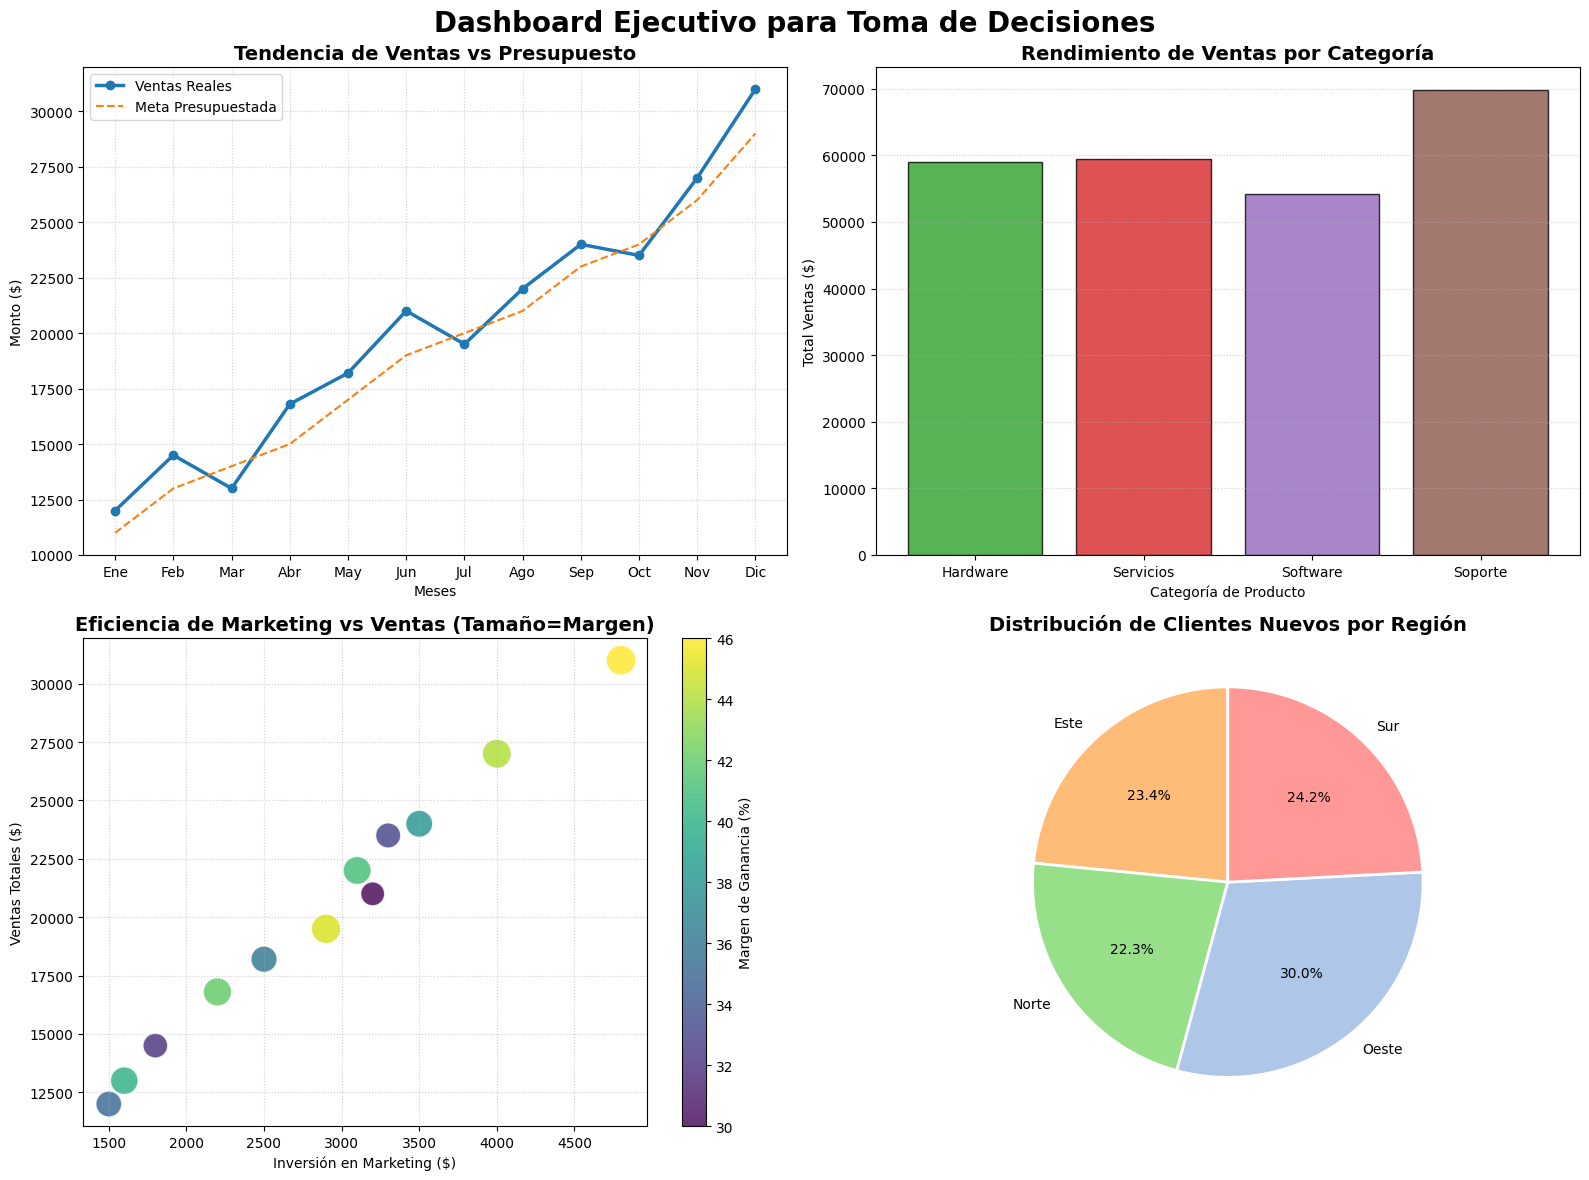

In [11]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import os
import matplotlib.pyplot as plt

try:
    # Se ha corregido la ruta apuntando a 'Colab Notebooks'
    df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/datos_empresa.xlsx')
    print("Archivo cargado correctamente.")
    # Mostrar las primeras filas del DataFrame para confirmar
    display(df.head())
except FileNotFoundError:
    print("Error: No se pudo encontrar el archivo en la ruta especificada.")



def generar_graficos_decision(ruta_excel):
    """Lee un archivo Excel y genera 4 gráficos clave para la toma de decisiones."""
    if not os.path.exists(ruta_excel):
        print(f"Error: El archivo '{ruta_excel}' no existe.")
        return

    df = pd.read_excel(ruta_excel)

    # Configurar el lienzo (Dashboard de 2x2 gráficos)
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Dashboard Ejecutivo para Toma de Decisiones",
        fontsize=20,
        fontweight="bold",
        y=0.98,
    )

    # 1. Tendencia de Ventas vs Presupuesto
    axs[0, 0].plot(
        df["Mes"],
        df["Ventas"],
        marker="o",
        color="#1f77b4",
        linewidth=2.5,
        label="Ventas Reales",
    )
    axs[0, 0].plot(
        df["Mes"],
        df["Presupuesto"],
        linestyle="--",
        color="#ff7f0e",
        label="Meta Presupuestada",
    )
    axs[0, 0].set_title(
        "Tendencia de Ventas vs Presupuesto", fontsize=14, fontweight="bold"
    )
    axs[0, 0].set_xlabel("Meses")
    axs[0, 0].set_ylabel("Monto ($)")
    axs[0, 0].grid(True, linestyle=":", alpha=0.6)
    axs[0, 0].legend()

    # 2. Ventas por Categoría
    df_cat = df.groupby("Producto Principal")["Ventas"].sum().reset_index()
    colores_barras = ["#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    axs[0, 1].bar(
        df_cat["Producto Principal"],
        df_cat["Ventas"],
        color=colores_barras[: len(df_cat)],
        edgecolor="black",
        alpha=0.8,
    )
    axs[0, 1].set_title(
        "Rendimiento de Ventas por Categoría", fontsize=14, fontweight="bold"
    )
    axs[0, 1].set_xlabel("Categoría de Producto")
    axs[0, 1].set_ylabel("Total Ventas ($)")
    axs[0, 1].grid(axis="y", linestyle=":", alpha=0.6)

    # 3. Marketing vs Ventas
    sc = axs[1, 0].scatter(
        df["Inversion_Marketing"],
        df["Ventas"],
        s=df["Margen_Ganancia"] * 10,
        c=df["Margen_Ganancia"],
        cmap="viridis",
        alpha=0.8,
        edgecolors="w",
    )
    axs[1, 0].set_title(
        "Eficiencia de Marketing vs Ventas (Tamaño=Margen)",
        fontsize=14,
        fontweight="bold",
    )
    axs[1, 0].set_xlabel("Inversión en Marketing ($)")
    axs[1, 0].set_ylabel("Ventas Totales ($)")
    axs[1, 0].grid(True, linestyle=":", alpha=0.6)
    cbar = fig.colorbar(sc, ax=axs[1, 0])
    cbar.set_label("Margen de Ganancia (%)")

    # 4. Distribución por Región
    df_region = df.groupby("Region")["Clientes_Nuevos"].sum().reset_index()

    axs[1, 1].pie(
        df_region["Clientes_Nuevos"],
        labels=df_region["Region"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#ffbb78", "#98df8a", "#aec7e8", "#ff9896"],
        wedgeprops={"edgecolor": "white", "linewidth": 2},
    )
    axs[1, 1].set_title(
        "Distribución de Clientes Nuevos por Región",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()

    # Guardar reporte
    nombre_salida = "reporte_toma_decisiones.png"
    plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
    print(f"Éxito: Dashboard exportado correctamente como '{nombre_salida}'")

    plt.show()

# --- LLAMADA A LA FUNCIÓN ---
# Llamamos usando la ruta correcta en tu Google Drive:
generar_graficos_decision('/content/drive/MyDrive/Colab Notebooks/datos_empresa.xlsx')

Éxito: Dashboard exportado correctamente como 'reporte_toma_decisiones.png'


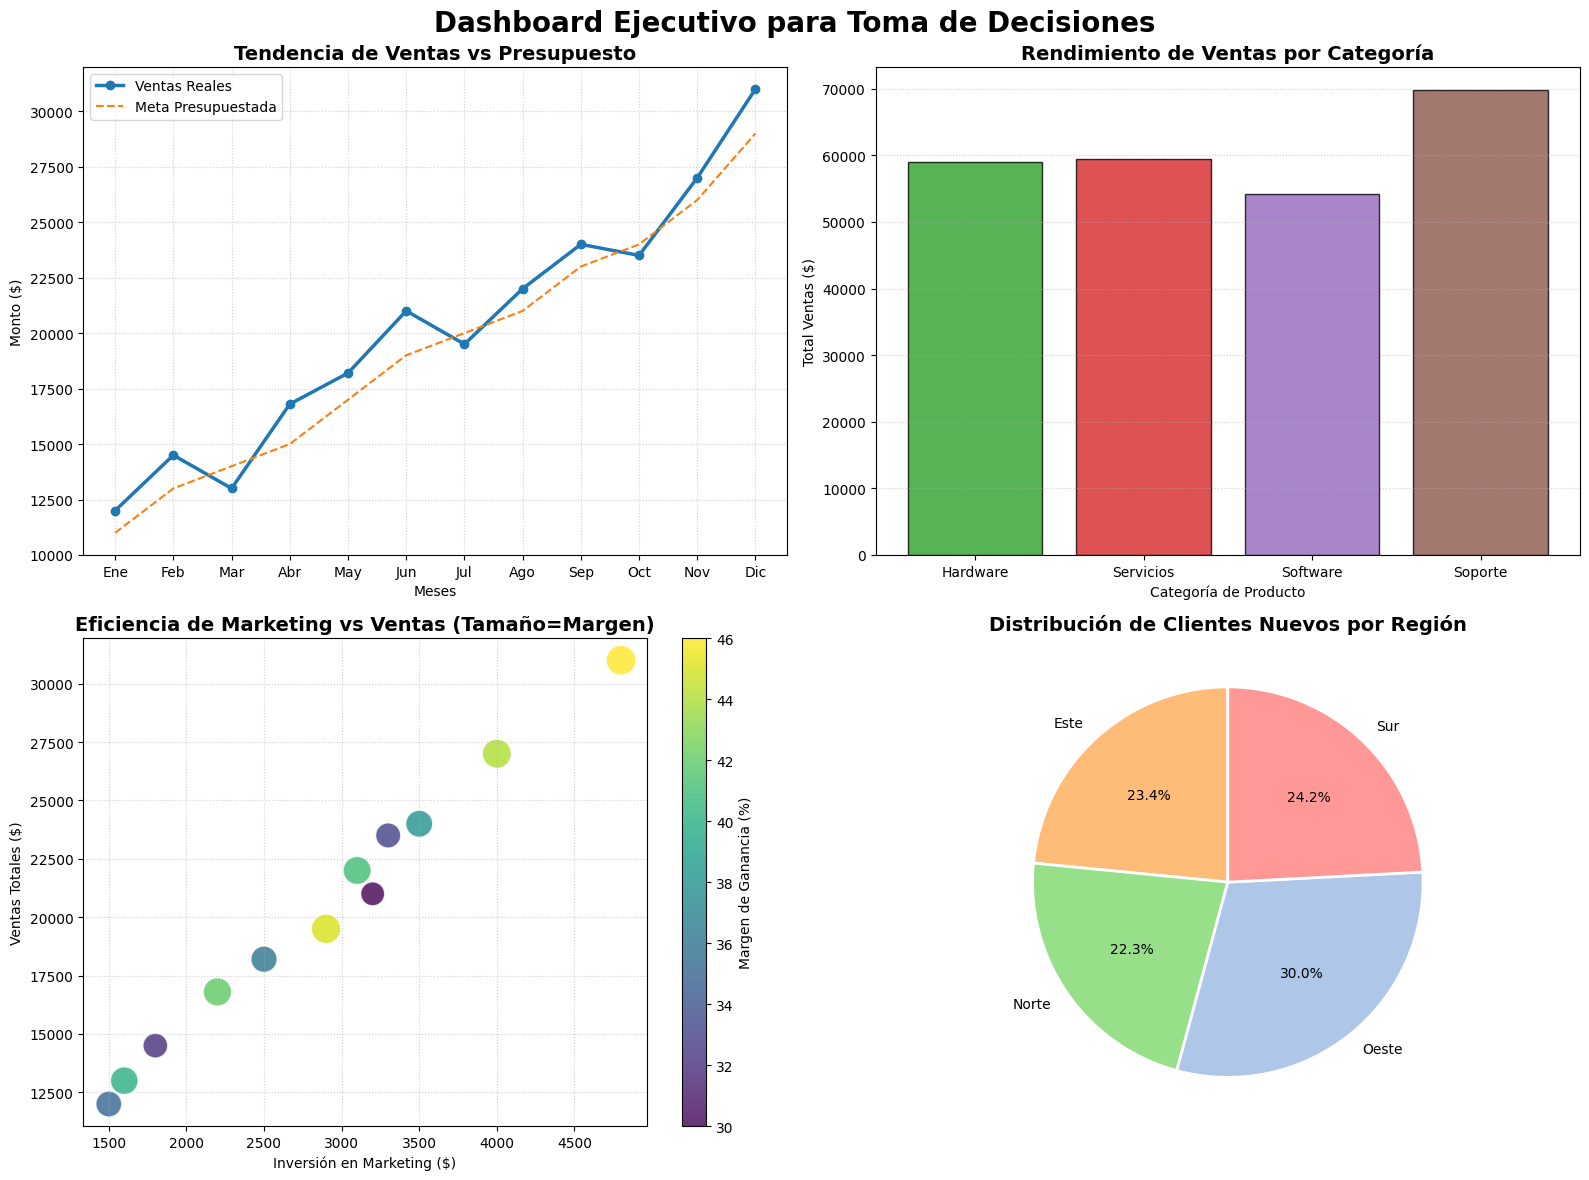

In [13]:
def generar_graficos_decision(ruta_excel):
    """Lee un archivo Excel y genera 4 gráficos clave para la toma de decisiones."""
    if not os.path.exists(ruta_excel):
        print(f"Error: El archivo '{ruta_excel}' no existe.")
        return

    df = pd.read_excel(ruta_excel)

    # Configurar el lienzo (Dashboard de 2x2 gráficos)
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Dashboard Ejecutivo para Toma de Decisiones",
        fontsize=20,
        fontweight="bold",
        y=0.98,
    )

    # 1. Tendencia de Ventas vs Presupuesto
    axs[0, 0].plot(
        df["Mes"],
        df["Ventas"],
        marker="o",
        color="#1f77b4",
        linewidth=2.5,
        label="Ventas Reales",
    )
    axs[0, 0].plot(
        df["Mes"],
        df["Presupuesto"],
        linestyle="--",
        color="#ff7f0e",
        label="Meta Presupuestada",
    )
    axs[0, 0].set_title(
        "Tendencia de Ventas vs Presupuesto", fontsize=14, fontweight="bold"
    )
    axs[0, 0].set_xlabel("Meses")
    axs[0, 0].set_ylabel("Monto ($)")
    axs[0, 0].grid(True, linestyle=":", alpha=0.6)
    axs[0, 0].legend()

    # 2. Ventas por Categoría
    df_cat = df.groupby("Producto Principal")["Ventas"].sum().reset_index()
    colores_barras = ["#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    axs[0, 1].bar(
        df_cat["Producto Principal"],
        df_cat["Ventas"],
        color=colores_barras[: len(df_cat)],
        edgecolor="black",
        alpha=0.8,
    )
    axs[0, 1].set_title(
        "Rendimiento de Ventas por Categoría", fontsize=14, fontweight="bold"
    )
    axs[0, 1].set_xlabel("Categoría de Producto")
    axs[0, 1].set_ylabel("Total Ventas ($)")
    axs[0, 1].grid(axis="y", linestyle=":", alpha=0.6)

    # 3. Marketing vs Ventas
    sc = axs[1, 0].scatter(
        df["Inversion_Marketing"],
        df["Ventas"],
        s=df["Margen_Ganancia"] * 10,
        c=df["Margen_Ganancia"],
        cmap="viridis",
        alpha=0.8,
        edgecolors="w",
    )
    axs[1, 0].set_title(
        "Eficiencia de Marketing vs Ventas (Tamaño=Margen)",
        fontsize=14,
        fontweight="bold",
    )
    axs[1, 0].set_xlabel("Inversión en Marketing ($)")
    axs[1, 0].set_ylabel("Ventas Totales ($)")
    axs[1, 0].grid(True, linestyle=":", alpha=0.6)
    cbar = fig.colorbar(sc, ax=axs[1, 0])
    cbar.set_label("Margen de Ganancia (%)")

    # 4. Distribución por Región
    df_region = df.groupby("Region")["Clientes_Nuevos"].sum().reset_index()

    axs[1, 1].pie(
        df_region["Clientes_Nuevos"],
        labels=df_region["Region"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#ffbb78", "#98df8a", "#aec7e8", "#ff9896"],
        wedgeprops={"edgecolor": "white", "linewidth": 2},
    )
    axs[1, 1].set_title(
        "Distribución de Clientes Nuevos por Región",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()

    # Guardar reporte
    nombre_salida = "reporte_toma_decisiones.png"
    plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
    print(f"Éxito: Dashboard exportado correctamente como '{nombre_salida}'")

    plt.show()

# --- LLAMADA A LA FUNCIÓN ---
# Llamamos usando la ruta correcta en tu Google Drive:
generar_graficos_decision('/content/drive/MyDrive/Colab Notebooks/datos_empresa.xlsx')